In [7]:
using JLD2
using Plots



In [ ]:

data_dir = joinpath(@__DIR__, "data")

all_sim_data = Dict{Float64, Dict{String, Any}}()

if isdir(data_dir)
    data_files = filter(f -> startswith(f, "data_eps_sigma_") && endswith(f, ".jld2"), readdir(data_dir))
    
    if isempty(data_files)
        println("No data files found in $data_dir.")
    else
        for file in data_files
            filepath = joinpath(data_dir, file)
            
            try
                file_data = load(filepath)
                
                if haskey(file_data, "sigma")
                    σ_val = file_data["sigma"]
                    all_sim_data[σ_val] = file_data
                    println("Successfully loaded data for σ = $σ_val from $file")
                else
                    println("Warning: 'sigma' key not found in $file. Skipping.")
                end
            catch e
                # If the file is corrupted/empty (e.g., EOFError), catch it and skip
                println("ERROR skipping corrupted file: $file")
                println("   -> Details: $e")
            end
        end
        println("\nDone! Total valid configurations loaded: $(length(all_sim_data))")
    end
else
    println("Directory $data_dir does not exist. Please check your path.")
end



┌ Warning: Opening file with JLD2.MmapIO failed, falling back to IOStream
└ @ JLD2 C:\Users\Ethan\.julia\packages\JLD2\hbsZG\src\JLD2.jl:162
Error encountered while load FileIO.File{FileIO.DataFormat{:JLD2}, String}("c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_breaking_VN\\data\\data_eps_sigma_3.0e-06.jld2").

Fatal error:


Successfully loaded data for σ = 0.01 from data_eps_sigma_1.0e-02.jld2
Successfully loaded data for σ = 0.001 from data_eps_sigma_1.0e-03.jld2
Successfully loaded data for σ = 1.0e-5 from data_eps_sigma_1.0e-05.jld2
Successfully loaded data for σ = 0.012 from data_eps_sigma_1.2e-02.jld2
Successfully loaded data for σ = 0.014 from data_eps_sigma_1.4e-02.jld2
Successfully loaded data for σ = 0.016 from data_eps_sigma_1.6e-02.jld2
Successfully loaded data for σ = 0.018 from data_eps_sigma_1.8e-02.jld2
Successfully loaded data for σ = 0.02 from data_eps_sigma_2.0e-02.jld2
Successfully loaded data for σ = 0.002 from data_eps_sigma_2.0e-03.jld2
Successfully loaded data for σ = 2.0e-7 from data_eps_sigma_2.0e-07.jld2
Successfully loaded data for σ = 0.022 from data_eps_sigma_2.2e-02.jld2
Successfully loaded data for σ = 0.024 from data_eps_sigma_2.4e-02.jld2
Successfully loaded data for σ = 2.4e-6 from data_eps_sigma_2.4e-06.jld2
Successfully loaded data for σ = 0.026 from data_eps_sigma_2.6e

┌ Warning: Opening file with JLD2.MmapIO failed, falling back to IOStream
└ @ JLD2 C:\Users\Ethan\.julia\packages\JLD2\hbsZG\src\JLD2.jl:162
Error encountered while load FileIO.File{FileIO.DataFormat{:JLD2}, String}("c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_breaking_VN\\data\\data_eps_sigma_9.6e-06.jld2").

Fatal error:


Successfully loaded data for σ = 5.8e-6 from data_eps_sigma_5.8e-06.jld2
Successfully loaded data for σ = 0.06 from data_eps_sigma_6.0e-02.jld2
Successfully loaded data for σ = 0.006 from data_eps_sigma_6.0e-03.jld2
Successfully loaded data for σ = 6.0e-6 from data_eps_sigma_6.0e-06.jld2
Successfully loaded data for σ = 0.062 from data_eps_sigma_6.2e-02.jld2
Successfully loaded data for σ = 6.2e-6 from data_eps_sigma_6.2e-06.jld2
Successfully loaded data for σ = 0.064 from data_eps_sigma_6.4e-02.jld2
Successfully loaded data for σ = 6.4e-6 from data_eps_sigma_6.4e-06.jld2
Successfully loaded data for σ = 0.066 from data_eps_sigma_6.6e-02.jld2
Successfully loaded data for σ = 6.6e-6 from data_eps_sigma_6.6e-06.jld2
Successfully loaded data for σ = 0.068 from data_eps_sigma_6.8e-02.jld2
Successfully loaded data for σ = 6.8e-6 from data_eps_sigma_6.8e-06.jld2
Successfully loaded data for σ = 7.0e-6 from data_eps_sigma_7.0e-06.jld2
Successfully loaded data for σ = 7.2e-6 from data_eps_sigm

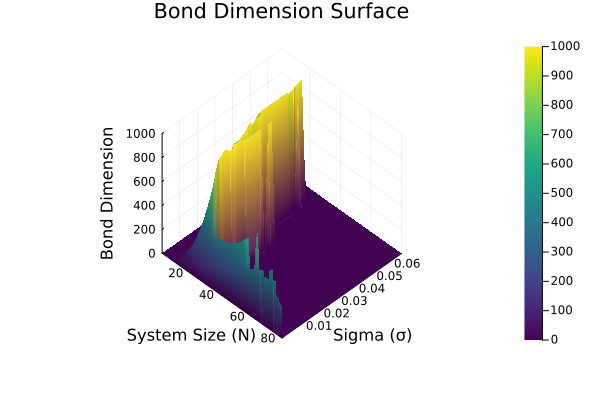

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_breaking_VN\\images\\bond_dimension_surface.pdf"

In [ ]:

# 1. Extract and sort the unique Sigma values for the Y-axis
sorted_sigmas = sort(collect(keys(all_sim_data)))

# 2. Extract the System Size (N_range) for the X-axis
# We can safely take this from the first available dataset
N_vals = all_sim_data[sorted_sigmas[1]]["N_range"]

# 3. Initialize a 2D matrix for the Z-axis (Bond Dimension)
# Rows will correspond to Sigma (Y), Columns to System Size (X)
Z_bond_dims = zeros(length(sorted_sigmas), length(N_vals))

# 4. Populate the Z matrix with the average bond dimension arrays
for (i, σ) in enumerate(sorted_sigmas)
    Z_bond_dims[i, :] = all_sim_data[σ]["avg_arr"]
end

# 5. Generate the surface plot
p_surface = surface(
    N_vals, 
    sorted_sigmas, 
    Z_bond_dims,
    title = "Bond Dimension Surface",
    xlabel = "System Size (N)",
    ylabel = "Sigma (σ)",
    zlabel = "Bond Dimension",
    camera = (45, 45), # Adjust for better viewing angles
    color = :viridis,  # Adds a nice color gradient based on height
    colorbar = true,
    margin = 5Plots.mm
)

display(p_surface)
savefig(p_surface, joinpath("images", "bond_dimension_surface.pdf"))

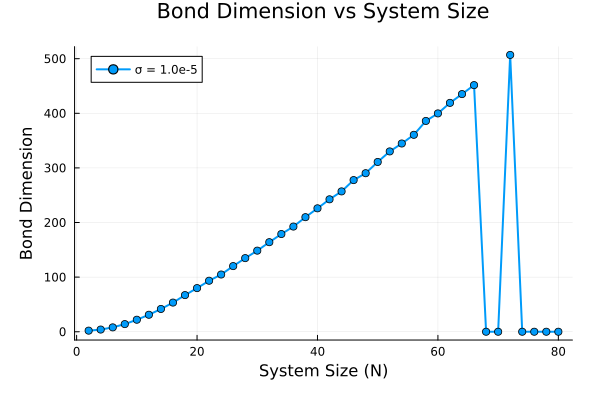

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_breaking_VN\\images\\bond_dim_specific_sigmas_2d.png"

In [15]:
using Plots

# Define the specific sigma values we want to plot
target_sigmas = [0.0, 1e-7, 1e-6, 1e-5]

# Initialize a 2D plot
p_2d = plot(
    title = "Bond Dimension vs System Size",
    xlabel = "System Size (N)",
    ylabel = "Bond Dimension",
    legend = :topleft,     # Places the legend out of the way
    margin = 5Plots.mm
)

# Loop through our target sigmas and add them to the plot
for σ in target_sigmas
    # Check if this sigma was successfully loaded into our dictionary
    if haskey(all_sim_data, σ)
        data = all_sim_data[σ]
        
        N_vals = data["N_range"]
        bond_dims = data["avg_arr"]
        
        # Add a line for this specific sigma to the existing plot
        # Using the ! after plot modifies the existing plot instead of creating a new one
        plot!(p_2d, N_vals, bond_dims, 
              label = "σ = $(σ)", 
              marker = :circle, 
              linewidth = 2)
    else
        println("Warning: Data for σ = $σ is missing or was corrupted and skipped earlier.")
    end
end

# Display the plot
display(p_2d)
savefig(p_2d, joinpath("images", "bond_dim_specific_sigmas_2d.png"))

┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Ethan\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Ethan\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Ethan\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Ethan\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194


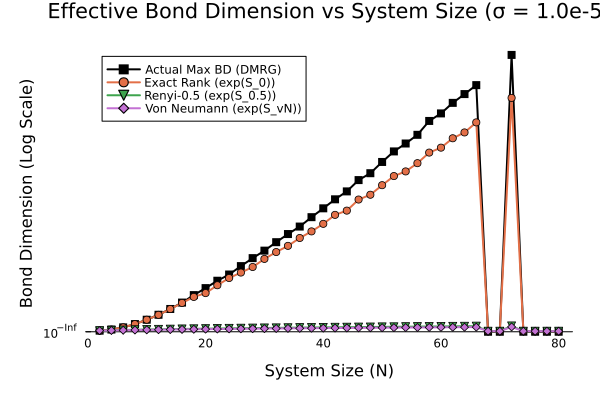

┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Ethan\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Ethan\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Ethan\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194


In [16]:
using Plots

# Choose a specific sigma to investigate 
# (You can change this to any sigma value you have loaded)
target_sigma = 1e-5

if haskey(all_sim_data, target_sigma)
    data = all_sim_data[target_sigma]
    
    N_vals  = data["N_range"]
    
    # 1. Actual Max Bond Dimension (from DMRG maxlinkdim)
    actual_bd = data["avg_arr"]
    
    # 2. Effective Bond Dimensions (e^S)
    eff_bd_s0   = exp.(data["s0_avg"])   # Schmidt Rank
    eff_bd_s05  = exp.(data["s05_avg"])  # 0.5-Renyi effective dimension
    eff_bd_vn   = exp.(data["vn_avg"])   # von Neumann effective dimension

    # Create the plot
    p_eff = plot(
        title = "Effective Bond Dimension vs System Size (σ = $target_sigma)",
        xlabel = "System Size (N)",
        ylabel = "Bond Dimension (Log Scale)",
        yaxis = :log10, # Log scale is highly recommended for exponential growth
        legend = :topleft,
        margin = 5Plots.mm
    )

    # Plot each line
    plot!(p_eff, N_vals, actual_bd,  label="Actual Max BD (DMRG)", marker=:square,  linewidth=2, color=:black)
    plot!(p_eff, N_vals, eff_bd_s0,  label="Exact Rank (exp(S_0))", marker=:circle,  linewidth=2)
    plot!(p_eff, N_vals, eff_bd_s05, label="Renyi-0.5 (exp(S_0.5))", marker=:dtriangle, linewidth=2)
    plot!(p_eff, N_vals, eff_bd_vn,  label="Von Neumann (exp(S_vN))", marker=:diamond, linewidth=2)

    display(p_eff)
    
    # Optional: save the plot
    # savefig(p_eff, "effective_bond_dimension_sigma_$(target_sigma).png")
else
    println("Error: Data for σ = $target_sigma not found in the loaded dictionary.")
end